# Check states
Created 30/04/2026

Objectives:
* Check states saved [here](../../save_states/finite_y_transverse_cluster_save_dmrg_200_site.ipynb).

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import quimb as qu
import quimb.tensor as qtn

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [6]:
DATA_DIR = r"../../data/y_transverse_cluster_100_site_dmrg"

In [7]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data.append(data)

In [8]:
loaded_data[0]

{'energy': -72.14471236987293,
 'paramters': {'t': 0.7000000000000001},
 'wavefunction': <tenpy.networks.mps.MPS at 0x300700f10>}

In [10]:
interpolation_values = sorted(list(d['paramters']['t'] for d in loaded_data))

In [11]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [13]:
psi_dict = dict()

for t in interpolation_values:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['t'] == t
    )

    rounded_t = round(t, 2)
    #psi_dict[rounded_t] = get_quimb_mps(psi)
    psi_dict[rounded_t] = psi

# Definitions

In [14]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [15]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [16]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

# Analysis
## Energies

In [17]:
loaded_data[0]

{'energy': -72.14471236987293,
 'paramters': {'t': 0.7000000000000001},
 'wavefunction': <tenpy.networks.mps.MPS at 0x300700f10>}

In [19]:
values = list()
energies = list()

for d in loaded_data:
    values.append(d['paramters']['t'])
    energies.append(d['energy'])

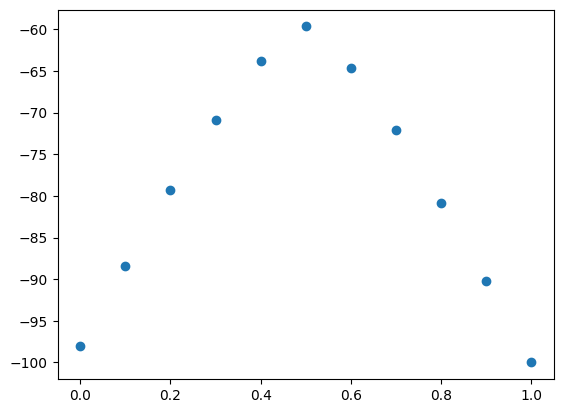

In [20]:
plt.plot(values, energies, 'o')

Critical point at $t=0.5$...?

In [23]:
list(zip(values, energies))

[(0.7000000000000001, -72.14471236987293),
 (0.6000000000000001, -64.60262997360586),
 (0.4, -63.76067793860156),
 (0.5, -59.65452589753313),
 (0.1, -88.39473590931804),
 (0.0, -98.00000000000009),
 (0.2, -79.28174311022435),
 (0.30000000000000004, -70.90301547140221),
 (1.0, -99.9999999999999),
 (0.8, -80.82235785866276),
 (0.9, -90.18172752134868)]

Energies look right.

## Expectation values

In [26]:
loaded_data[0]['wavefunction'].expectation_value('Sx', 50)

array([-3.1458126e-15])

In [27]:
values = list()
exps = list()

for d in loaded_data:
    values.append(d['paramters']['t'])
    psi = d['wavefunction']
    exp_triple = (
        psi.expectation_value('Sx', 50),
        psi.expectation_value('Sy', 50),
        psi.expectation_value('Sz', 50)
    )
    exps.append(exp_triple)

In [28]:
exps = np.array(exps)

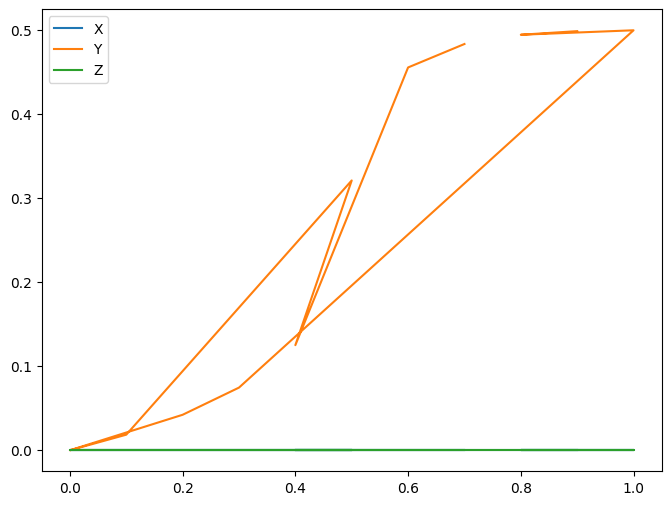

In [29]:
fig, ax = plt.subplots(figsize=(8,6))

for i, l in zip(range(3), 'XYZ'):
    ax.plot(values, exps[:, i], label=l)

ax.legend()

In [31]:
np.round(exps, 3)

array([[[-0.   ],
        [ 0.484],
        [-0.   ]],

       [[-0.   ],
        [ 0.456],
        [ 0.   ]],

       [[-0.   ],
        [ 0.125],
        [-0.   ]],

       [[ 0.   ],
        [ 0.321],
        [-0.   ]],

       [[-0.   ],
        [ 0.019],
        [ 0.   ]],

       [[-0.   ],
        [ 0.   ],
        [-0.   ]],

       [[ 0.   ],
        [ 0.042],
        [ 0.   ]],

       [[-0.   ],
        [ 0.075],
        [-0.   ]],

       [[-0.   ],
        [ 0.5  ],
        [ 0.   ]],

       [[ 0.   ],
        [ 0.495],
        [-0.   ]],

       [[-0.   ],
        [ 0.499],
        [-0.   ]]])

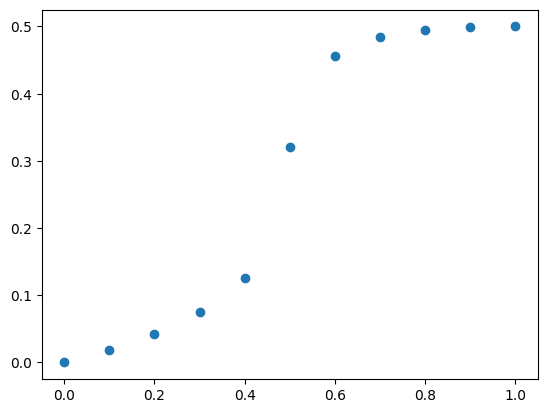

In [33]:
plt.plot(values, exps[:, 1], 'o')

# Conclusions
Looks good.